In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../credit_data/data.csv', low_memory=False)

print(f"Dataset Shape: {df.shape}")
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True))

Dataset Shape: (100000, 146)

Target Distribution:
target
0    0.79926
1    0.20074
Name: proportion, dtype: float64


In [3]:
def calculate_iv(data, feature, target):
    """Calculates Information Value (IV) and Weight of Evidence (WoE) for a categorical feature."""

    grouped = data.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'count': 'Total', 'sum': 'Bad'})
    grouped['Good'] = grouped['Total'] - grouped['Bad']

    grouped['Dist_Good'] = grouped['Good'] / grouped['Good'].sum()
    grouped['Dist_Bad'] = grouped['Bad'] / grouped['Bad'].sum()

    grouped['Dist_Good'] = np.where(grouped['Dist_Good'] == 0, 0.0001, grouped['Dist_Good'])
    grouped['Dist_Bad'] = np.where(grouped['Dist_Bad'] == 0, 0.0001, grouped['Dist_Bad'])

    grouped['WoE'] = np.log(grouped['Dist_Good'] / grouped['Dist_Bad'])
    grouped['IV'] = (grouped['Dist_Good'] - grouped['Dist_Bad']) * grouped['WoE']
    
    iv_total = grouped['IV'].sum()
    return iv_total, grouped.reset_index()

In [4]:
iv_score, woe_table = calculate_iv(df, 'grade', 'target')
print(f"Total Information Value for 'grade': {iv_score:.4f}\n")
print(woe_table[['grade', 'Good', 'Bad', 'WoE', 'IV']])

Total Information Value for 'grade': 0.4545

  grade   Good   Bad       WoE        IV
0     A  16129  1062  1.338789  0.199339
1     B  25184  3886  0.487153  0.059193
2     C  22103  6411 -0.143978  0.006166
3     D  10520  4556 -0.544843  0.051944
4     E   4350  2726 -0.914335  0.074401
5     F   1297  1118 -1.233163  0.048669
6     G    343   315 -1.296518  0.014781


In [5]:
categorical_cols = [
    "term", "grade", "sub_grade", "emp_length", "home_ownership", 
    "verification_status", "purpose", "addr_state"
]

iv_results = []
for col in categorical_cols:
    if col in df.columns:
        iv_score, _ = calculate_iv(df, col, 'target')
        iv_results.append({'Feature': col, 'IV_Score': iv_score})

iv_df = pd.DataFrame(iv_results).sort_values(by='IV_Score', ascending=False).reset_index(drop=True)
print(iv_df)

               Feature  IV_Score
0            sub_grade  0.491916
1                grade  0.454493
2                 term  0.177776
3  verification_status  0.058198
4       home_ownership  0.037259
5           addr_state  0.020554
6              purpose  0.016432
7           emp_length  0.003050


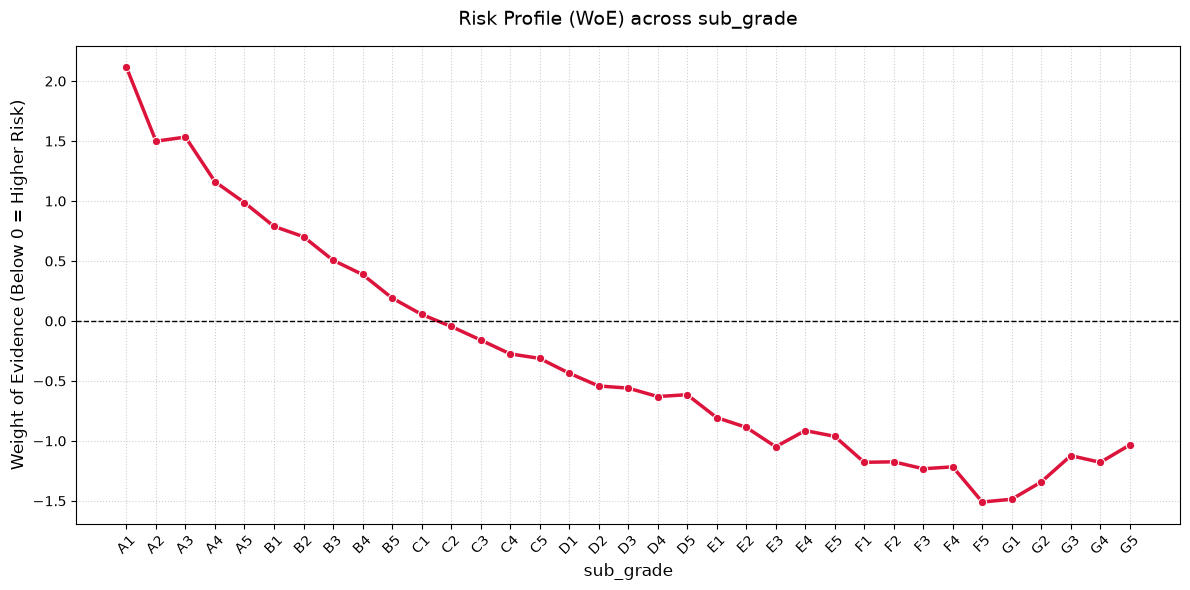

In [6]:
def plot_woe(woe_table, feature_name):
    plt.figure(figsize=(12, 6))

    sns.lineplot(data=woe_table, x=feature_name, y='WoE', marker='o', 
                 linewidth=2.5, color='crimson')

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.title(f'Risk Profile (WoE) across {feature_name}', fontsize=14, pad=15)
    plt.ylabel('Weight of Evidence (Below 0 = Higher Risk)', fontsize=12)
    plt.xlabel(feature_name, fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

_, sub_grade_woe = calculate_iv(df, 'sub_grade', 'target')
plot_woe(sub_grade_woe, 'sub_grade')